In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

c:\Users\heroj\anaconda3\envs\proyecto_python1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_ch =df[df['job_country'] == 'Chile'].copy()

In [3]:
df_ch['job_posted_month'] = df_ch['job_posted_date'].dt.strftime('%B')

df_ch

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
91,Data Scientist,Data Scientist,"Temuco, Chile",via BeBee Chile,Full-time,False,Chile,2023-01-06 14:07:40,False,False,Chile,NaN,NaN,NaN,Talently,"['sql', 'python', 'tensorflow', 'numpy', 'pand...","{'analyst_tools': ['excel', 'tableau'], 'libra...",January
133,Senior Data Scientist,Data Scientist Senior,"Santiago, Chile",via Chiletrabajos,Full-time,False,Chile,2023-07-06 13:28:33,False,False,Chile,NaN,NaN,NaN,Alaya Digital Solutions,"['python', 'sql', 'matlab', 'aws', 'azure']","{'cloud': ['aws', 'azure'], 'programming': ['p...",July
237,Data Scientist,Data Science Specialist,"Santiago, Chile",via Trabajo.org,Full-time,False,Chile,2023-01-29 13:25:16,False,False,Chile,NaN,NaN,NaN,BairesDev,NaN,NaN,January
301,Data Scientist,Data Scientist,"Santiago, Chile",via LinkedIn,Full-time,False,Chile,2023-05-17 13:33:57,False,False,Chile,NaN,NaN,NaN,"SMU S.A. (Unimarc, M10, Alvi, y Super10)",NaN,NaN,May
304,Data Engineer,Principal Data Engineer,"Santiago, Chile",via BeBee Chile,Full-time,False,Chile,2023-03-11 13:26:39,False,False,Chile,NaN,NaN,NaN,McKinsey & Company,"['python', 'sql', 'scala', 'java', 'databricks...","{'cloud': ['databricks', 'aws', 'gcp', 'azure'...",March
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785621,Data Engineer,Data Engineer,"Santiago, Chile","via Trabajo.org - Vacantes De Empleo, Trabajo",Full-time,False,Chile,2023-09-24 06:31:57,True,False,Chile,NaN,NaN,NaN,Elite Recruitment Group,"['php', 'python', 'sql', 'aws', 'airflow', 'ha...","{'cloud': ['aws'], 'libraries': ['airflow', 'h...",September
785637,Data Engineer,Data Engineer,"Santiago, Chile","via Trabajo.org - Vacantes De Empleo, Trabajo",Full-time,False,Chile,2023-08-09 06:31:57,True,False,Chile,NaN,NaN,NaN,Tribal Credit,"['python', 'scala', 'mysql', 'snowflake', 'ora...","{'cloud': ['snowflake', 'oracle', 'aws', 'azur...",August
785644,Data Analyst,Data Analyst,"Las Condes, Chile","via Trabajo.org - Vacantes De Empleo, Trabajo",Full-time,False,Chile,2023-08-20 06:29:50,True,False,Chile,NaN,NaN,NaN,Worldgroup Careers MWT,"['sql', 'python', 'r', 'snowflake', 'power bi']","{'analyst_tools': ['power bi'], 'cloud': ['sno...",August
785698,Data Engineer,"Data Engineer, Gerencia Business Intelligence","Las Condes, Chile","via Trabajo.org - Vacantes De Empleo, Trabajo",Full-time,False,Chile,2023-08-09 06:32:00,True,False,Chile,NaN,NaN,NaN,Falabella Retail,"['sql', 'python', 'gcp', 'aws', 'git']","{'cloud': ['gcp', 'aws'], 'other': ['git'], 'p...",August


In [4]:
df_ch_pivot = df_ch.pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='size')

In [5]:
df_ch_pivot.reset_index(inplace=True)
df_ch_pivot['month_no'] = pd.to_datetime(df_ch_pivot['job_posted_month'], format='%B').dt.month

df_ch_pivot

job_title_short,job_posted_month,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,month_no
0,April,56,10,174,288,269,14,35,56,51,57,4
1,August,64,40,148,207,197,33,23,41,41,91,8
2,December,64,25,131,180,146,22,15,27,22,81,12
3,February,26,8,56,69,79,11,7,8,14,29,2
4,January,39,11,78,119,116,10,10,10,22,63,1
5,July,74,35,182,178,181,36,28,38,64,103,7
6,June,30,3,111,113,103,18,27,12,38,14,6
7,March,41,8,72,128,102,19,10,25,9,28,3
8,May,38,3,110,137,102,13,12,19,20,26,5
9,November,50,16,102,171,159,22,8,28,33,73,11


In [6]:
df_ch_pivot.sort_values('month_no', inplace=True)
df_ch_pivot.set_index('job_posted_month', inplace=True)
df_ch_pivot.drop(columns='month_no', inplace=True)

In [7]:
df_ch_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,39,11,78,119,116,10,10,10,22,63
February,26,8,56,69,79,11,7,8,14,29
March,41,8,72,128,102,19,10,25,9,28
April,56,10,174,288,269,14,35,56,51,57
May,38,3,110,137,102,13,12,19,20,26
June,30,3,111,113,103,18,27,12,38,14
July,74,35,182,178,181,36,28,38,64,103
August,64,40,148,207,197,33,23,41,41,91
September,70,30,127,252,165,14,16,33,33,74


In [10]:
df_ch_software_pivot = pd.read_csv("https://lukeb.co/software_csv", index_col='job_posted_month')
df_ch_software_pivot

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


In [12]:
df_ch_merged = df_ch_pivot.merge(df_ch_software_pivot, on='job_posted_month')

In [15]:
top_4 = df_ch_merged.sum().sort_values(ascending=False).head(4).index.to_list()

top_4


['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'UI/UX Designer']

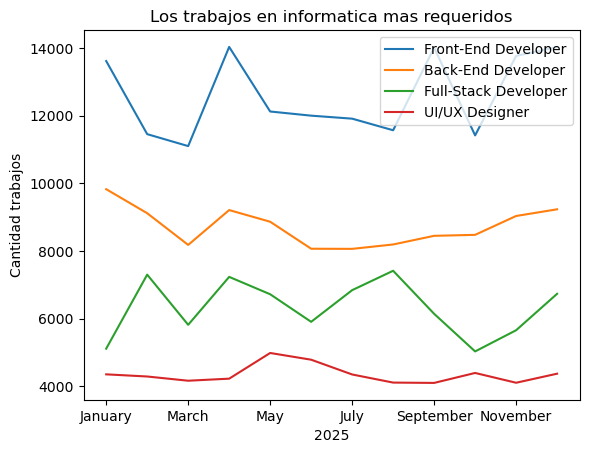

In [19]:
df_ch_merged[top_4].plot(kind='line')
plt.title('Los trabajos en informatica mas requeridos')
plt.xlabel('2025')
plt.ylabel('Cantidad trabajos')
plt.legend
plt.show()